<a href="https://colab.research.google.com/github/NghiaH19/E-commerce/blob/main/TrainingLightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Project2_Ecommerce/ecommerce_final_processed.csv'
df = pd.read_csv(path)

df['date'] = pd.to_datetime(df['date'])
print(f"✅ Đã nạp {len(df):,} dòng dữ liệu sẵn sàng huấn luyện!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã nạp 2,662,922 dòng dữ liệu sẵn sàng huấn luyện!


In [ ]:
print(df.columns.tolist())

['date', 'product_id', 'luot_view', 'luot_mua', 'luot_cart', 'price', 'category_code', 'brand', 'day_of_week', 'is_weekend', 'view_lag_1', 'view_lag_7', 'mua_lag_1', 'view_rolling_7']


In [ ]:
split_date = '2019-11-24'

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

features = ['price', 'day_of_week', 'is_weekend', 'view_lag_1', 'view_lag_7', 'mua_lag_1', 'view_rolling_7', 'category_code', 'brand']
target = 'luot_mua'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Tập Học (Train): {len(X_train):,} dòng")
print(f"Tập Thi (Test): {len(X_test):,} dòng")

Tập Học (Train): 2,352,029 dòng
Tập Thi (Test): 310,893 dòng


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib

model_lgb = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=12,
    random_state=42
)

# 4. Huấn luyện
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 5. Dự báo và Đánh giá
y_pred = model_lgb.predict(X_test)
y_pred = np.maximum(y_pred, 0)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- KẾT QUẢ ---")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R2 Score: {r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.141024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1524
[LightGBM] [Info] Number of data points in the train set: 2352029, number of used features: 9
[LightGBM] [Info] Start training from score 0.405715
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.199512	valid_0's l2: 5.29881

--- KẾT QUẢ ---
✅ MAE: 0.1995
✅ RMSE: 2.3019
✅ R2 Score: 0.9326


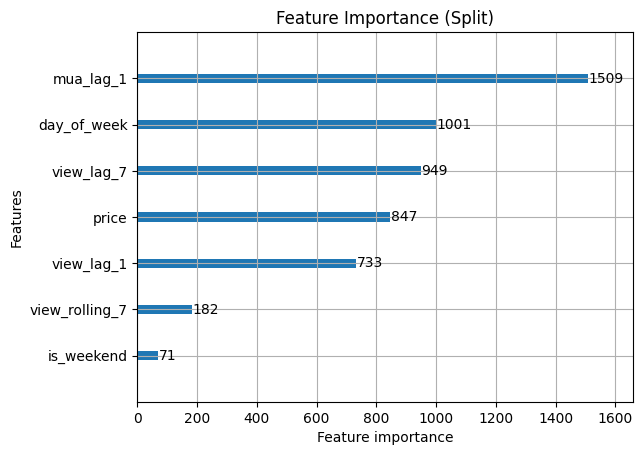

In [ ]:
import matplotlib.pyplot as plt
lgb.plot_importance(model_lgb, importance_type='split', title='Feature Importance (Split)')
plt.show()

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


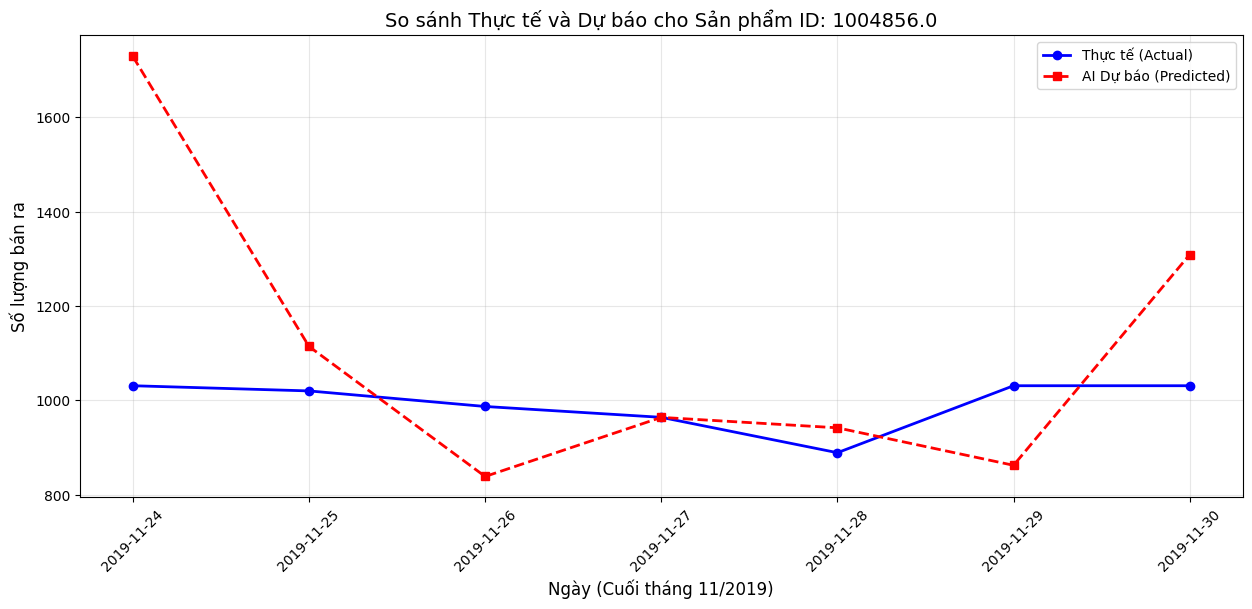

In [ ]:
import matplotlib.pyplot as plt

# 1. Chọn ra một sản phẩm có lượt mua đáng kể trong tập Test để kiểm tra
top_product_id = test.groupby('product_id')['luot_mua'].sum().idxmax()
sample_data = test[test['product_id'] == top_product_id].sort_values('date')

# 2. Dự báo cho sản phẩm đó
y_sample_pred = model_lgb.predict(sample_data[features])
y_sample_pred = np.maximum(y_sample_pred, 0) # Không lấy giá trị âm

# 3. Vẽ biểu đồ
plt.figure(figsize=(15, 6))
plt.plot(sample_data['date'], sample_data['luot_mua'], label='Thực tế (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(sample_data['date'], y_sample_pred, label='AI Dự báo (Predicted)', color='red', linestyle='--', marker='s', linewidth=2)

plt.title(f"So sánh Thực tế và Dự báo cho Sản phẩm ID: {top_product_id}", fontsize=14)
plt.xlabel("Ngày (Cuối tháng 11/2019)", fontsize=12)
plt.ylabel("Số lượng bán ra", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [ ]:
display(sample_data[['date', 'luot_view', 'luot_mua', 'view_lag_1', 'mua_lag_1', 'view_rolling_7']])


,date,luot_view,luot_mua,view_lag_1,mua_lag_1,view_rolling_7
46592,2019-11-24,13440.0,1031.0,13747.0,1038.0,14522.428571
46593,2019-11-25,13387.0,1020.0,13440.0,1031.0,13768.571429
46594,2019-11-26,14252.0,987.0,13387.0,1020.0,13648.857143
46595,2019-11-27,14392.0,964.0,14252.0,987.0,13698.000000
46596,2019-11-28,14274.0,889.0,14392.0,964.0,13824.571429
46597,2019-11-29,15578.0,1031.0,14274.0,889.0,14152.857143
46598,2019-11-30,14405.0,1031.0,15578.0,1031.0,14246.857143


In [ ]:
import joblib

# Đường dẫn lưu file trên Drive
model_path = '/content/drive/MyDrive/Project2_Ecommerce/lightgbm_demand_model.pkl'

# Trích xuất mô hình
joblib.dump(model_lgb, model_path)

print(f"✅ Đã trích xuất mô hình thành công tại: {model_path}")

✅ Đã trích xuất mô hình thành công tại: /content/drive/MyDrive/Project2_Ecommerce/lightgbm_demand_model.pkl
